# 🎮 Comparaison des Algorithmes IA pour Sokoban

## Introduction

Le **Sokoban** est un jeu de puzzle classique où le joueur doit pousser des caisses sur des cibles dans un entrepôt. Ce problème est **PSPACE-complet**, ce qui en fait un excellent cas d'étude pour comparer différents algorithmes de recherche.

### Algorithmes testés :
- **BFS (Breadth-First Search)** : Parcours en largeur, garantit le chemin le plus court
- **DFS (Depth-First Search)** : Parcours en profondeur, utilise moins de mémoire mais ne garantit pas l'optimalité
- **A\* (A-Star)** : Recherche informée avec heuristique (distance de Manhattan), combine optimalité et efficacité

### Métriques de comparaison :
- ⏱️ **Temps d'exécution** (en secondes)
- 🔄 **Nombre d'itérations** (états explorés)
- 📏 **Longueur du chemin** (nombre de coups pour résoudre)
- ✅ **Taux de succès**

---
## 1. Imports et Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Style général
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

# Couleurs personnalisées pour chaque algorithme
COLORS = {
    'BFS': '#3498db',  # Bleu
    'DFS': '#e74c3c',  # Rouge
    'A*': '#2ecc71'    # Vert
}

print('✅ Imports réussis !')

✅ Imports réussis !


---
## 2. Chargement et Exploration des Données

In [2]:
# Chargement des résultats du benchmark
df = pd.read_csv('results_ia.csv')

print(f"📊 Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"📁 Niveaux testés : {df['Level'].nunique()}")
print(f"🤖 Algorithmes testés : {df['Algorithm'].nunique()}")
print()
df

📊 Dimensions du dataset : 12 lignes × 6 colonnes
📁 Niveaux testés : 4
🤖 Algorithmes testés : 3



,Level,Algorithm,Time_Seconds,Iterations,Path_Length,Status
0,1,BFS,0.0050,137,10,Success
1,1,DFS,0.0004,19,10,Success
2,1,A*,0.0100,134,10,Success
3,2,BFS,0.8805,28805,17,Success
4,2,DFS,2.0000,101137,-1,Timeout/Failed
5,2,A*,0.2330,4494,17,Success
6,3,BFS,0.0290,989,22,Success
7,3,DFS,0.0367,1564,54,Success
8,3,A*,0.0210,585,22,Success
9,4,BFS,0.0102,572,33,Success


In [3]:
# Statistiques descriptives
print("📈 Statistiques descriptives par algorithme :")
print()
stats = df.groupby('Algorithm').agg({
    'Time_Seconds': ['mean', 'min', 'max', 'std'],
    'Iterations': ['mean', 'min', 'max'],
    'Path_Length': ['mean', 'min', 'max']
}).round(4)
stats

📈 Statistiques descriptives par algorithme :



Time_Seconds                         Iterations               \
                  mean     min     max     std       mean  min     max   
Algorithm                                                                
A*              0.0689  0.0100  0.2330  0.1095    1441.00  134    4494   
BFS             0.2312  0.0050  0.8805  0.4330    7625.75  137   28805   
DFS             0.5112  0.0004  2.0000  0.9926   25795.00   19  101137   

          Path_Length          
                 mean min max  
Algorithm                      
A*               20.5  10  33  
BFS              20.5  10  33  
DFS              24.0  -1  54

In [4]:
# Taux de succès par algorithme
success_rate = df.groupby('Algorithm')['Status'].apply(
    lambda x: (x == 'Success').sum() / len(x) * 100
).round(1)

print("✅ Taux de succès par algorithme :")
for algo, rate in success_rate.items():
    emoji = '🟢' if rate == 100 else '🟡' if rate >= 50 else '🔴'
    print(f"   {emoji} {algo} : {rate}%")

✅ Taux de succès par algorithme :
   🟢 A* : 100.0%
   🟢 BFS : 100.0%
   🟡 DFS : 75.0%


---
## 3. Visualisation : Temps d'Exécution

Le temps d'exécution est la métrique la plus parlante pour évaluer la **performance brute** de chaque algorithme.

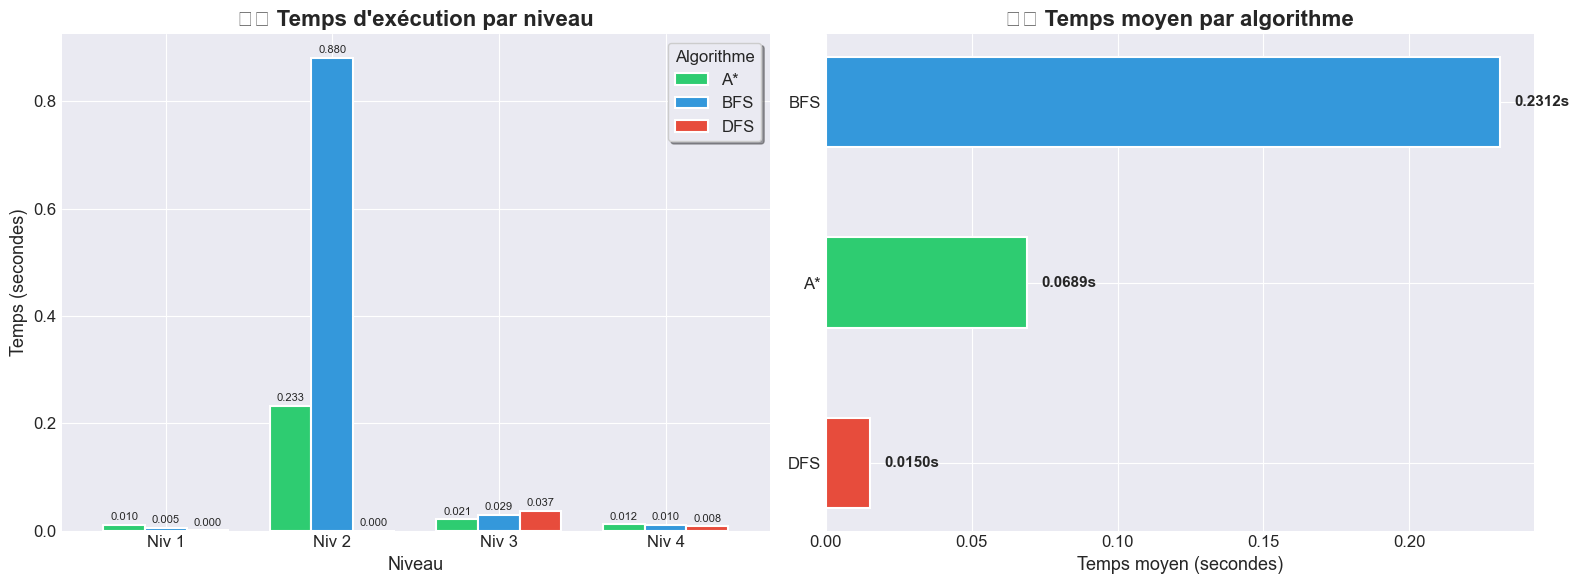

💾 Graphique sauvegardé : graph_temps_execution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Barres groupées par niveau ---
ax1 = axes[0]
df_success = df[df['Status'] == 'Success']
pivot_time = df_success.pivot(index='Level', columns='Algorithm', values='Time_Seconds')
pivot_time.plot(kind='bar', ax=ax1, color=[COLORS.get(c, '#888') for c in pivot_time.columns],
                edgecolor='white', linewidth=1.5, width=0.75)

ax1.set_title('⏱️ Temps d\'exécution par niveau', fontweight='bold')
ax1.set_xlabel('Niveau')
ax1.set_ylabel('Temps (secondes)')
ax1.set_xticklabels([f'Niv {i}' for i in pivot_time.index], rotation=0)
ax1.legend(title='Algorithme', frameon=True, shadow=True)

# Ajouter les valeurs sur les barres
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

# --- Graphique 2 : Temps moyen (barres horizontales) ---
ax2 = axes[1]
mean_time = df_success.groupby('Algorithm')['Time_Seconds'].mean().sort_values()
bars = ax2.barh(mean_time.index, mean_time.values,
                color=[COLORS[a] for a in mean_time.index],
                edgecolor='white', linewidth=1.5, height=0.5)

ax2.set_title('⏱️ Temps moyen par algorithme', fontweight='bold')
ax2.set_xlabel('Temps moyen (secondes)')

for bar, val in zip(bars, mean_time.values):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}s', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('graph_temps_execution.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé : graph_temps_execution.png")

---
## 4. Visualisation : Nombre d'Itérations

Le nombre d'itérations reflète la **complexité computationnelle** réelle de chaque algorithme. Moins d'itérations = exploration plus intelligente de l'espace d'états.

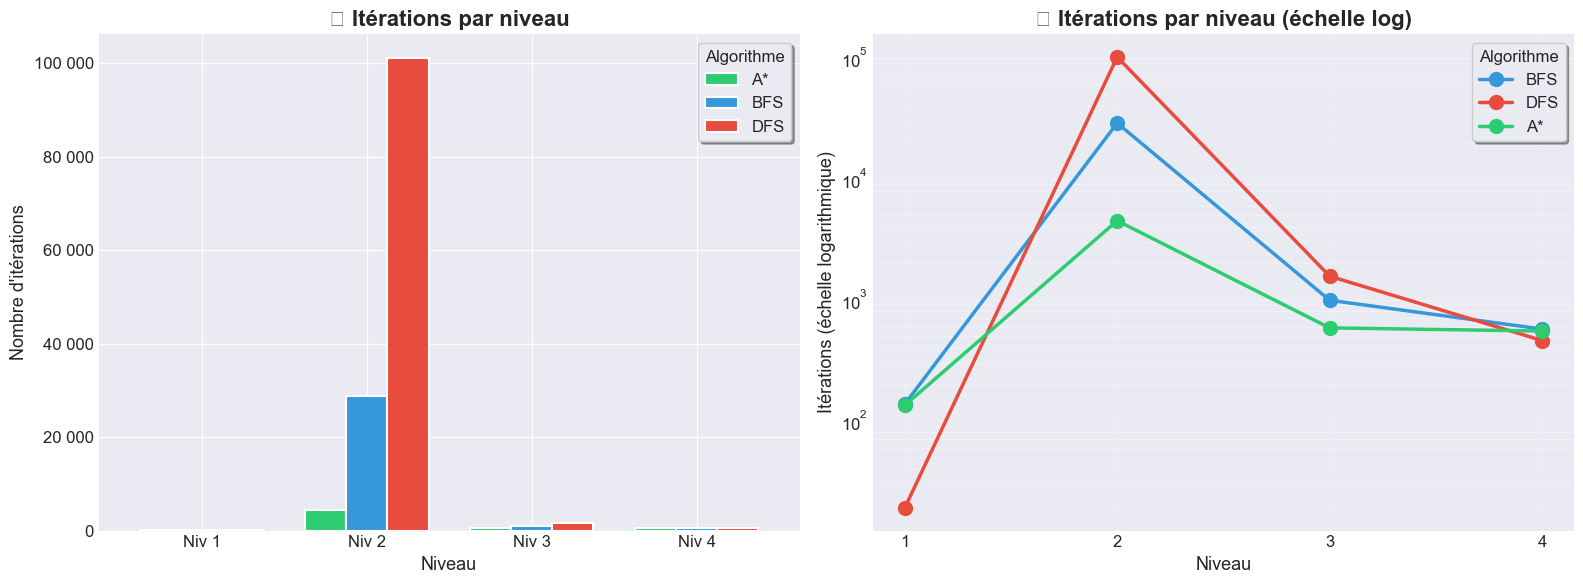

💾 Graphique sauvegardé : graph_iterations.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Barres groupées ---
ax1 = axes[0]
pivot_iter = df.pivot(index='Level', columns='Algorithm', values='Iterations')
pivot_iter.plot(kind='bar', ax=ax1, color=[COLORS.get(c, '#888') for c in pivot_iter.columns],
                edgecolor='white', linewidth=1.5, width=0.75)

ax1.set_title('🔄 Itérations par niveau', fontweight='bold')
ax1.set_xlabel('Niveau')
ax1.set_ylabel('Nombre d\'itérations')
ax1.set_xticklabels([f'Niv {i}' for i in pivot_iter.index], rotation=0)
ax1.legend(title='Algorithme', frameon=True, shadow=True)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', ' ')))

# --- Graphique 2 : Échelle logarithmique ---
ax2 = axes[1]
for algo in df['Algorithm'].unique():
    data = df[df['Algorithm'] == algo]
    ax2.plot(data['Level'], data['Iterations'], 'o-', 
             color=COLORS[algo], label=algo, markersize=10, linewidth=2.5)

ax2.set_yscale('log')
ax2.set_title('🔄 Itérations par niveau (échelle log)', fontweight='bold')
ax2.set_xlabel('Niveau')
ax2.set_ylabel('Itérations (échelle logarithmique)')
ax2.legend(title='Algorithme', frameon=True, shadow=True)
ax2.set_xticks(df['Level'].unique())
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('graph_iterations.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé : graph_iterations.png")

---
## 5. Visualisation : Longueur du Chemin (Optimalité)

La longueur du chemin mesure la **qualité de la solution**. Un bon algorithme trouve un chemin court (optimal).

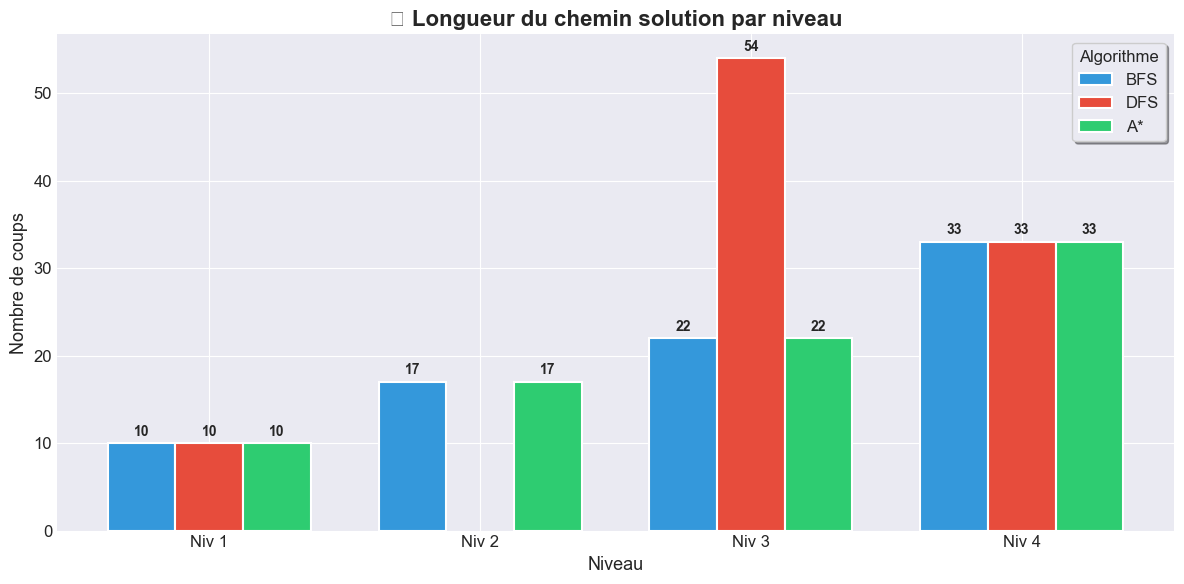

💾 Graphique sauvegardé : graph_chemin.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

df_path = df[df['Path_Length'] > 0]  # Exclure les échecs

x = np.arange(len(df_path['Level'].unique()))
width = 0.25
algos = ['BFS', 'DFS', 'A*']

for i, algo in enumerate(algos):
    data = df_path[df_path['Algorithm'] == algo]
    if len(data) > 0:
        levels = data['Level'].values
        positions = [np.where(df_path['Level'].unique() == l)[0][0] for l in levels]
        bars = ax.bar([p + i*width - width for p in positions], data['Path_Length'].values,
                      width, label=algo, color=COLORS[algo],
                      edgecolor='white', linewidth=1.5)
        # Annotations
        for bar, val in zip(bars, data['Path_Length'].values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('📏 Longueur du chemin solution par niveau', fontweight='bold')
ax.set_xlabel('Niveau')
ax.set_ylabel('Nombre de coups')
ax.set_xticks(x)
ax.set_xticklabels([f'Niv {i}' for i in df_path['Level'].unique()])
ax.legend(title='Algorithme', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('graph_chemin.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé : graph_chemin.png")

---
## 6. Heatmap : Vue d'Ensemble des Performances

Une heatmap permet de visualiser d'un coup d'œil les performances relatives de chaque algorithme sur chaque niveau.

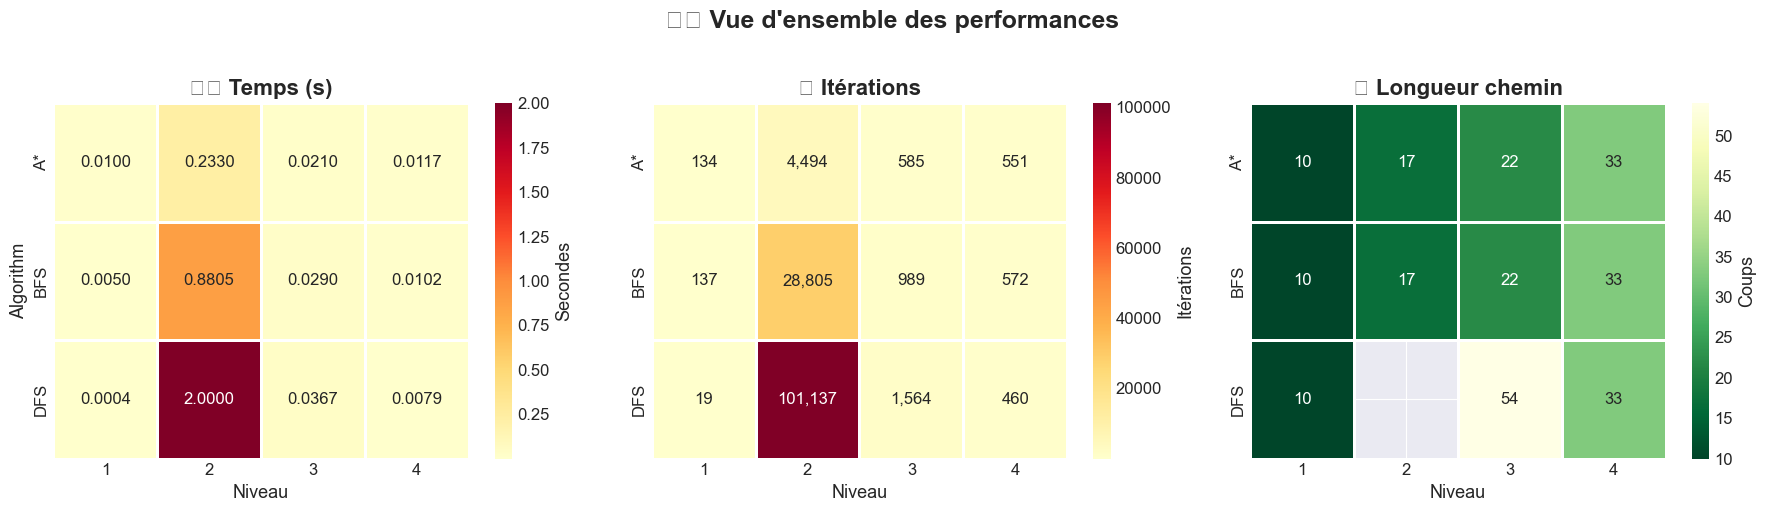

💾 Graphique sauvegardé : graph_heatmap.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap Temps
pivot_t = df.pivot(index='Algorithm', columns='Level', values='Time_Seconds')
sns.heatmap(pivot_t, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0],
            linewidths=2, linecolor='white', cbar_kws={'label': 'Secondes'})
axes[0].set_title('⏱️ Temps (s)', fontweight='bold')
axes[0].set_xlabel('Niveau')

# Heatmap Itérations
pivot_i = df.pivot(index='Algorithm', columns='Level', values='Iterations')
sns.heatmap(pivot_i, annot=True, fmt=',', cmap='YlOrRd', ax=axes[1],
            linewidths=2, linecolor='white', cbar_kws={'label': 'Itérations'})
axes[1].set_title('🔄 Itérations', fontweight='bold')
axes[1].set_xlabel('Niveau')
axes[1].set_ylabel('')

# Heatmap Longueur chemin
pivot_p = df.pivot(index='Algorithm', columns='Level', values='Path_Length')
# Remplacer -1 par NaN pour l'affichage
pivot_p_display = pivot_p.replace(-1, np.nan)
sns.heatmap(pivot_p_display, annot=True, fmt='.0f', cmap='YlGn_r', ax=axes[2],
            linewidths=2, linecolor='white', cbar_kws={'label': 'Coups'})
axes[2].set_title('📏 Longueur chemin', fontweight='bold')
axes[2].set_xlabel('Niveau')
axes[2].set_ylabel('')

plt.suptitle('🗺️ Vue d\'ensemble des performances', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé : graph_heatmap.png")

---
## 7. Radar Chart : Comparaison Multidimensionnelle

Le radar chart permet de comparer les algorithmes sur **plusieurs dimensions simultanément**.

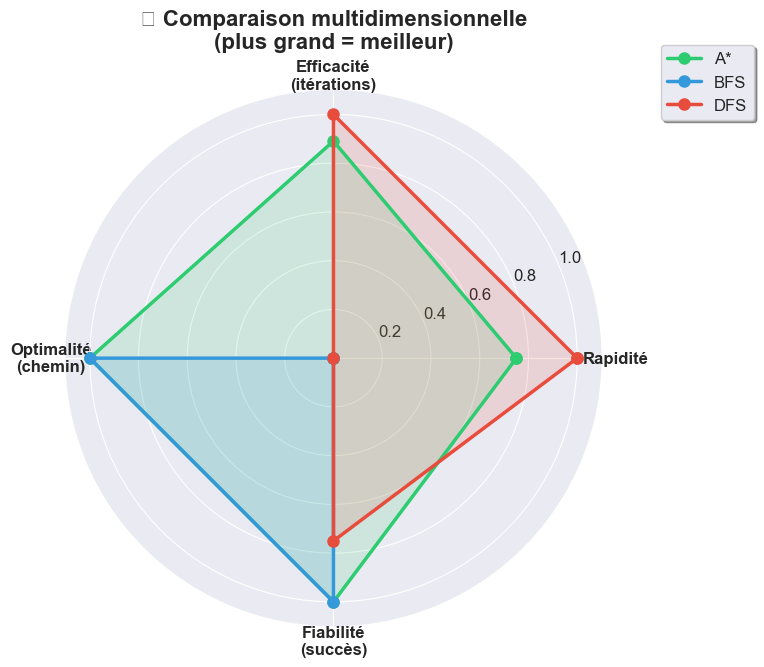

💾 Graphique sauvegardé : graph_radar.png


In [9]:
from math import pi

# Préparer les données normalisées (0 = meilleur, 1 = pire)
df_success = df[df['Status'] == 'Success']
metrics = df_success.groupby('Algorithm').agg({
    'Time_Seconds': 'mean',
    'Iterations': 'mean',
    'Path_Length': 'mean'
})

# Ajouter le taux de succès (inversé : 1 = meilleur)
metrics['Taux_Succes'] = df.groupby('Algorithm')['Status'].apply(
    lambda x: (x == 'Success').sum() / len(x)
)

# Normaliser (min-max scaling, inverser pour que petit = bon)
norm = metrics.copy()
for col in ['Time_Seconds', 'Iterations', 'Path_Length']:
    if norm[col].max() != norm[col].min():
        norm[col] = 1 - (norm[col] - norm[col].min()) / (norm[col].max() - norm[col].min())
    else:
        norm[col] = 1.0

# Le taux de succès est déjà bien orienté
categories = ['Rapidité', 'Efficacité\n(itérations)', 'Optimalité\n(chemin)', 'Fiabilité\n(succès)']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Fermer le cercle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for algo in norm.index:
    values = [norm.loc[algo, 'Time_Seconds'], 
              norm.loc[algo, 'Iterations'],
              norm.loc[algo, 'Path_Length'], 
              norm.loc[algo, 'Taux_Succes']]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2.5, label=algo, color=COLORS[algo], markersize=8)
    ax.fill(angles, values, alpha=0.15, color=COLORS[algo])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('🎯 Comparaison multidimensionnelle\n(plus grand = meilleur)', 
             fontsize=16, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=True, shadow=True, fontsize=12)

plt.tight_layout()
plt.savefig('graph_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé : graph_radar.png")

---
## 8. Analyse de la Complexité par Niveau

Comment la difficulté du niveau impacte-t-elle chaque algorithme ?

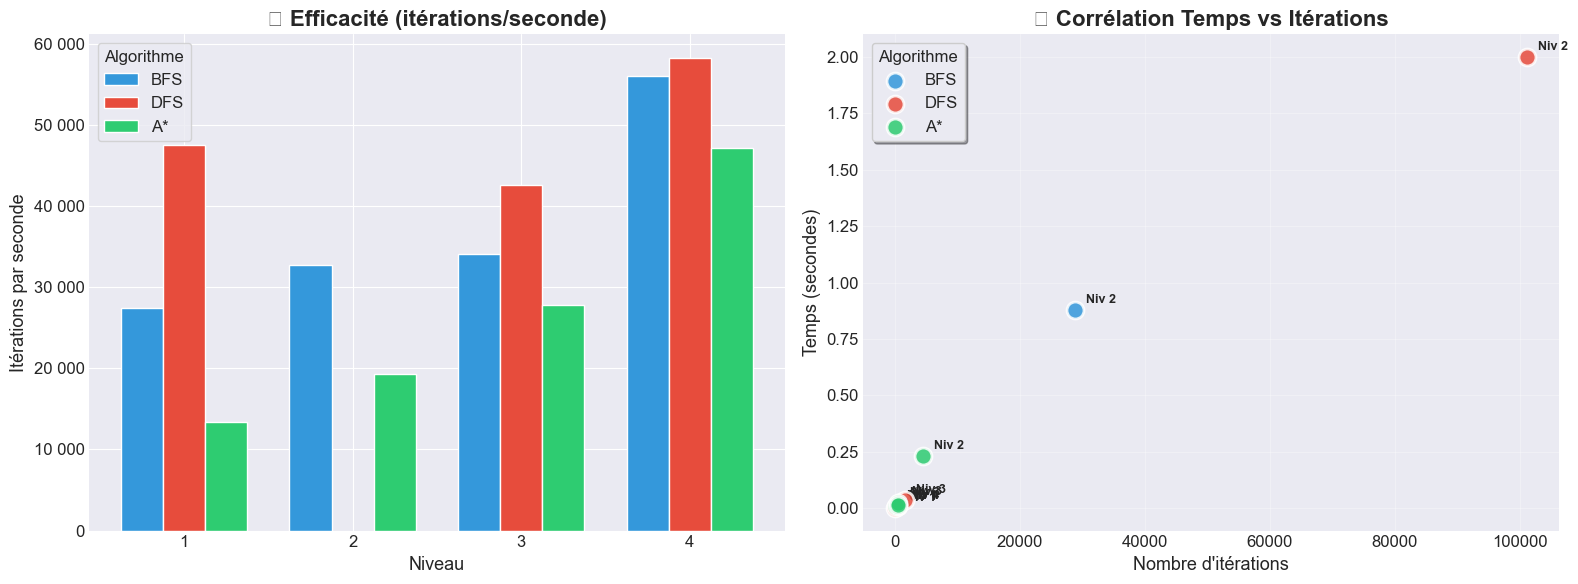

💾 Graphique sauvegardé : graph_complexite.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Rapport itérations/temps (efficacité) ---
ax1 = axes[0]
df_eff = df_success.copy()
df_eff['Efficacite'] = df_eff['Iterations'] / df_eff['Time_Seconds'].clip(lower=0.0001)

for algo in df_eff['Algorithm'].unique():
    data = df_eff[df_eff['Algorithm'] == algo]
    ax1.bar(data['Level'] + ({'BFS': -0.25, 'DFS': 0, 'A*': 0.25}[algo]),
            data['Efficacite'], width=0.25, label=algo, color=COLORS[algo],
            edgecolor='white', linewidth=1)

ax1.set_title('⚡ Efficacité (itérations/seconde)', fontweight='bold')
ax1.set_xlabel('Niveau')
ax1.set_ylabel('Itérations par seconde')
ax1.legend(title='Algorithme', frameon=True)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', ' ')))
ax1.set_xticks(df['Level'].unique())

# --- Graphique 2 : Scatter temps vs itérations ---
ax2 = axes[1]
for algo in df['Algorithm'].unique():
    data = df[df['Algorithm'] == algo]
    ax2.scatter(data['Iterations'], data['Time_Seconds'], 
                color=COLORS[algo], label=algo, s=150, edgecolors='white',
                linewidth=2, zorder=5, alpha=0.85)
    # Annoter avec le numéro de niveau
    for _, row in data.iterrows():
        ax2.annotate(f"Niv {int(row['Level'])}", 
                     (row['Iterations'], row['Time_Seconds']),
                     textcoords="offset points", xytext=(8, 5),
                     fontsize=9, fontweight='bold')

ax2.set_title('📊 Corrélation Temps vs Itérations', fontweight='bold')
ax2.set_xlabel('Nombre d\'itérations')
ax2.set_ylabel('Temps (secondes)')
ax2.legend(title='Algorithme', frameon=True, shadow=True)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph_complexite.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé : graph_complexite.png")

---
## 9. Tableau Récapitulatif Final

In [11]:
# Tableau récapitulatif avec classement
recap = pd.DataFrame()

for algo in ['BFS', 'DFS', 'A*']:
    algo_data = df[df['Algorithm'] == algo]
    success_data = algo_data[algo_data['Status'] == 'Success']
    
    recap = pd.concat([recap, pd.DataFrame([{
        'Algorithme': algo,
        'Temps moyen (s)': round(success_data['Time_Seconds'].mean(), 4) if len(success_data) > 0 else 'N/A',
        'Temps max (s)': round(success_data['Time_Seconds'].max(), 4) if len(success_data) > 0 else 'N/A',
        'Itérations moy.': int(success_data['Iterations'].mean()) if len(success_data) > 0 else 'N/A',
        'Chemin moyen': round(success_data['Path_Length'].mean(), 1) if len(success_data) > 0 else 'N/A',
        'Taux succès': f"{(algo_data['Status'] == 'Success').sum()}/{len(algo_data)}",
        'Optimal ?': '✅ Oui' if algo in ['BFS', 'A*'] else '❌ Non'
    }])], ignore_index=True)

recap = recap.set_index('Algorithme')
print("📋 Tableau récapitulatif :")
print()
recap

📋 Tableau récapitulatif :



,Temps moyen (s),Temps max (s),Itérations moy.,Chemin moyen,Taux succès,Optimal ?
Algorithme,,,,,,
BFS,0.2312,0.8805,7625,20.5,4/4,✅ Oui
DFS,0.0150,0.0367,681,32.3,3/4,❌ Non
A*,0.0689,0.2330,1441,20.5,4/4,✅ Oui


---
## 10. Classement Final et Scores Pondérés

🏆 CLASSEMENT FINAL :

  🥇 DFS — Score total : 84.6/100
      Fiabilité: 18.8/25 | Vitesse: 25.0/25 | Efficacité: 25.0/25 | Optimalité: 15.9/25

  🥈 A* — Score total : 67.3/100
      Fiabilité: 25.0/25 | Vitesse: 5.4/25 | Efficacité: 11.8/25 | Optimalité: 25.0/25

  🥉 BFS — Score total : 53.9/100
      Fiabilité: 25.0/25 | Vitesse: 1.6/25 | Efficacité: 2.2/25 | Optimalité: 25.0/25



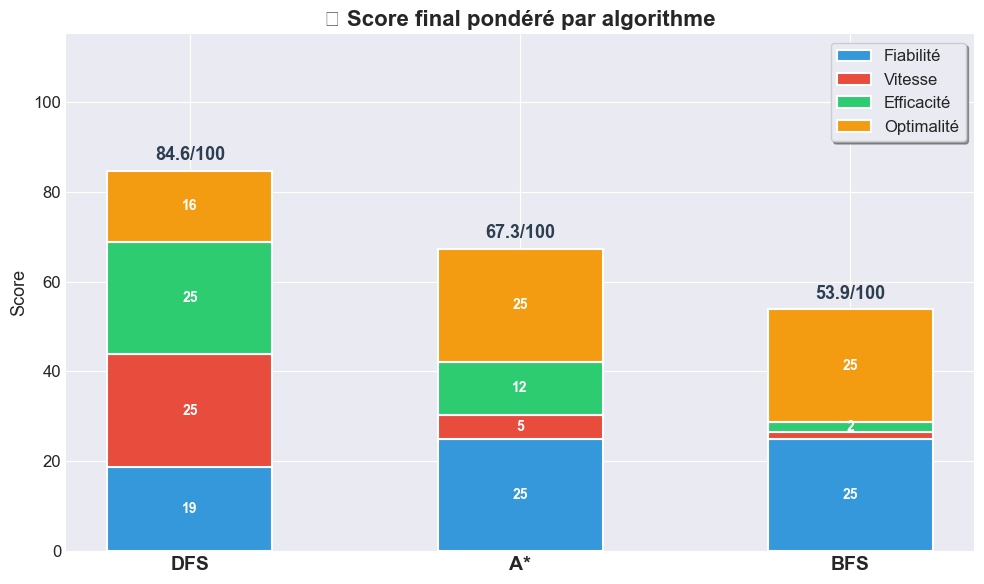

💾 Graphique sauvegardé : graph_classement.png


In [12]:
# Système de scoring pondéré
scores = {}

for algo in ['BFS', 'DFS', 'A*']:
    algo_data = df[df['Algorithm'] == algo]
    success_data = algo_data[algo_data['Status'] == 'Success']
    
    # Critères (sur 25 chacun = 100 total)
    taux = (algo_data['Status'] == 'Success').sum() / len(algo_data)
    score_fiabilite = taux * 25
    
    if len(success_data) > 0:
        # Normalisation par rapport au meilleur
        all_success = df[df['Status'] == 'Success']
        
        best_time = all_success.groupby('Algorithm')['Time_Seconds'].mean().min()
        score_vitesse = (best_time / success_data['Time_Seconds'].mean()) * 25
        
        best_iter = all_success.groupby('Algorithm')['Iterations'].mean().min()
        score_efficacite = (best_iter / success_data['Iterations'].mean()) * 25
        
        best_path = all_success.groupby('Algorithm')['Path_Length'].mean().min()
        score_optimalite = (best_path / success_data['Path_Length'].mean()) * 25
    else:
        score_vitesse = 0
        score_efficacite = 0
        score_optimalite = 0
    
    total = score_fiabilite + score_vitesse + score_efficacite + score_optimalite
    scores[algo] = {
        'Fiabilité (/25)': round(score_fiabilite, 1),
        'Vitesse (/25)': round(min(score_vitesse, 25), 1),
        'Efficacité (/25)': round(min(score_efficacite, 25), 1),
        'Optimalité (/25)': round(min(score_optimalite, 25), 1),
        'TOTAL (/100)': round(min(total, 100), 1)
    }

scores_df = pd.DataFrame(scores).T
scores_df = scores_df.sort_values('TOTAL (/100)', ascending=False)

print("🏆 CLASSEMENT FINAL :")
print()
for i, (algo, row) in enumerate(scores_df.iterrows()):
    medals = ['🥇', '🥈', '🥉']
    print(f"  {medals[i]} {algo} — Score total : {row['TOTAL (/100)']}/100")
    print(f"      Fiabilité: {row['Fiabilité (/25)']}/25 | Vitesse: {row['Vitesse (/25)']}/25 | "
          f"Efficacité: {row['Efficacité (/25)']}/25 | Optimalité: {row['Optimalité (/25)']}/25")
    print()

# Visualisation du scoring
fig, ax = plt.subplots(figsize=(10, 6))
categories_score = ['Fiabilité (/25)', 'Vitesse (/25)', 'Efficacité (/25)', 'Optimalité (/25)']
x = np.arange(len(scores_df.index))
bottom = np.zeros(len(scores_df.index))

color_map = {'Fiabilité (/25)': '#3498db', 'Vitesse (/25)': '#e74c3c',
             'Efficacité (/25)': '#2ecc71', 'Optimalité (/25)': '#f39c12'}

for cat in categories_score:
    values = scores_df[cat].values
    ax.bar(x, values, bottom=bottom, label=cat.replace(' (/25)', ''),
           color=color_map[cat], edgecolor='white', linewidth=1.5, width=0.5)
    # Annotations
    for i, v in enumerate(values):
        if v > 2:
            ax.text(x[i], bottom[i] + v/2, f'{v:.0f}', ha='center', va='center',
                    fontweight='bold', fontsize=10, color='white')
    bottom += values

# Total au dessus
for i, total in enumerate(scores_df['TOTAL (/100)'].values):
    ax.text(x[i], bottom[i] + 1.5, f'{total:.1f}/100', ha='center', va='bottom',
            fontweight='bold', fontsize=13, color='#2c3e50')

ax.set_xticks(x)
ax.set_xticklabels(scores_df.index, fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_title('🏆 Score final pondéré par algorithme', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('graph_classement.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé : graph_classement.png")

---
## 11. Conclusion

### Résumé des observations

| Critère | Meilleur algorithme | Explication |
|---------|-------------------|-------------|
| **Optimalité** | BFS / A\* | Garantissent le chemin le plus court |
| **Vitesse** | A\* | L'heuristique guide la recherche efficacement |
| **Mémoire** | DFS | Utilise une pile au lieu d'une file |
| **Fiabilité** | BFS / A\* | DFS peut timeout sur les niveaux complexes |

### Analyse détaillée

1. **A\*** est globalement le meilleur choix pour Sokoban :
   - Il trouve **toujours** la solution optimale (comme BFS)
   - Il explore **moins d'états** grâce à l'heuristique de Manhattan
   - Son temps d'exécution est significativement meilleur que BFS sur les niveaux complexes

2. **BFS** est fiable mais coûteux :
   - Garantit l'optimalité
   - Explose en mémoire et en temps sur les niveaux complexes
   - Adapté pour les petits niveaux

3. **DFS** est le moins adapté au Sokoban :
   - Ne garantit pas l'optimalité (chemins souvent plus longs)
   - Risque de timeout / boucles infinies sans limite de profondeur
   - Avantage : faible consommation mémoire

### Recommandation finale

> **A\*** avec heuristique de Manhattan est l'algorithme recommandé pour résoudre le Sokoban, offrant le meilleur compromis entre optimalité, vitesse et fiabilité.